# TCA analysis

## You might need to run this on startup

In [ ]:
!pip install tensortools

  Preparing metadata (setup.py) ... done
  Created wheel for tensortools: filename=tensortools-0.4-py3-none-any.whl size=50739 sha256=5f5977de209ccc665030a8875c19cd10bf61e73eb44ccc1c4c994b582e4095df
  Stored in directory: /root/.cache/pip/wheels/ed/c4/e2/b4c6d2d35812884a33aa6cf643788981cf3a72803b3d326738
Successfully built tensortools


## Imports

In [ ]:
import tensortools as tt
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import requests
import os
import pandas as pd
import gc
import pickle
from datetime import datetime, timedelta
import joblib
from google.colab import drive
import seaborn as sns
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_root = '/content/drive/MyDrive/TCA_results'
os.makedirs(drive_root, exist_ok=True)

## Helper functions

In [ ]:
def linux_time_to_human_time(linux_time_list):
  '''
  Function to convert from linux time to human readable time stamps
  '''

  converted = []

  for datenum in linux_time_list:
      days = int(datenum)
      fraction = datenum % 1
      dt = datetime.fromordinal(days) + timedelta(days=fraction) - timedelta(days=366)
      converted.append(dt)

  return converted

In [ ]:
def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
  '''
  Function to create the 3D martices used to run TCA
  trial_timestamps: (Array-like) The timstamps on spiking_data where the buffers will be centered on
  buffer: (Array of size 2) The number of timesteps to the left (index 0) and right (index 1) of the timestamps which will be used to construct the 3D matrix
  spiking_data: (np.2DArray) The spiking data from the neurons, time must be on the zeroeth axis
  spiking_timestamps: (Array-like) The timestamps of each spike in spiking_data
  '''

  TCA_matrix = np.zeros((len(trial_timestamps), (buffer[0] + buffer[1] + 1), spiking_data.shape[1]))

  for index, timestamp in enumerate(trial_timestamps):
    idx = np.searchsorted(spiking_timestamps, timestamp, side='right')
    TCA_matrix[index, :, :] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :]

  return TCA_matrix

## Downloading data from figshare (Avoid running this multiple times)

In [ ]:
# @title Data loading and imports

# set path for data
root = r'/content'
Path(root).mkdir(exist_ok=True)
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

# files required for this project: 'VR2_2021_03_20_1_example_raw_spk.npy'; 'VR2_2021_03_20_1_SVD_dec.npy'; 'VR2_2021_03_20_trans.npz'; 'VR2_2021_04_06_1_SVD_dec.npy'; 'VR2_2021_04_06_trans.npz';
#        'TX105_2022_10_08_2_SVD_dec.npy'; 'TX105_2022_10_08_trans.npz'; 'TX105_2022_10_19_2_SVD_dec.npy'; 'TX105_2022_10_19_trans.npz'
#        'Beh_sup_train1_before_learning.npy'; 'Beh_sup_train1_after_learning.npy'; 'Beh_unsup_train1_before_learning.npy'; 'Beh_unsup_train1_after_learning.npy'
sup_bef = 'VR2_2021_03_20_1' #example mouse before supervised learning
sup_aft = 'VR2_2021_04_06_1' #example mouse after supervised learning
unsup_bef = 'TX105_2022_10_08_2' #example mouse before supervised learning
unsup_aft = 'TX105_2022_10_19_2' #example mouse after supervised learning

# download files from Figshare
file_ID = [54866153, 54866354, 54184211, 54866333, 54184214, 54866237, 54184028, 54866150, 54184031, 54183863, 54183860, 54183914, 54183917] # IDs of files

BASE_URL = 'https://api.figshare.com/v2'
r = requests.get(BASE_URL + '/articles/' + str(28811129)) # 28811129 is the ID of the whole dataset
file_metadata = json.loads(r.text)
for file in file_metadata['files']:
  if file['id'] in file_ID: # only download files included in file_ID
    fn = os.path.join(root, file['name'])
    if not os.path.isfile(fn):
      response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
      open(fn, 'wb').write(response.content)
    #print(fn)

In [ ]:
# @title set target here
target_file = sup_bef

if target_file == sup_bef:
  target_path = "Beh_sup_train1_before_learning.npy"
elif target_file == sup_aft:
  target_path = "Beh_sup_train1_after_learning.npy"
elif target_file == unsup_bef:
  target_path = "Beh_unsup_train1_before_learning.npy"
elif target_file == unsup_aft:
  target_path = "Beh_unsup_train1_after_learning.npy"

## Loading data

In [ ]:
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

In [ ]:
# @title loading spiking data, change the path as needed

spiking_raw_data = np.load(os.path.join(root, target_file + '_SVD_dec.npy'), allow_pickle=True)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# @title loading location data

spiking_loc_data = np.load(os.path.join(root, target_file[:-2] + '_trans.npz'), allow_pickle=True)

NameError: name 'target_file' is not defined

In [ ]:
# @title Load behavioral data

beh = np.load(os.path.join(root, target_path), allow_pickle=1).item()[target_file]
print(beh.keys())

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])


## Data consolidation

In [ ]:
# @title Reconstructing spiking data

spiking_data = spiking_raw_data.item()['U'].T @ spiking_raw_data.item()['V']

In [ ]:
spiking_data = spiking_data.T

In [ ]:
spiking_data.shape

(24298, 81473)

In [ ]:
# @title Splitting spiking data into trials and converting to a 3D matrix

trial_start_matrix = create_3d_matrix(beh['Trial_start_time'], (2, 2), spiking_data, beh['ft'][:-2])
trial_sound_matrix = create_3d_matrix(beh['SoundTime'], (2, 2), spiking_data, beh['ft'][:-2])

In [ ]:
trial_sound_matrix.shape

(348, 5, 81473)

In [ ]:
trial_start_matrix.shape

(348, 5, 81473)

## Visualising TCA

Fitting rank-1 models:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/tensortools/optimize/ncp_hals.py:185: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  Cp = factors[:, idx] @ grams[idx][:, p]
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 8.4s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 23.4s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 32.2s


Rank-4 models:  min obj, 0.79;  max obj, 0.79;  time to fit, 100.3s


Rank-5 models:  min obj, 0.78;  max obj, 0.78;  time to fit, 115.3s


Rank-6 models:  min obj, 0.76;  max obj, 0.77;  time to fit, 124.4s


Rank-7 models:  min obj, 0.75;  max obj, 0.75;  time to fit, 131.3s


Rank-8 models:  min obj, 0.74;  max obj, 0.75;  time to fit, 198.4s


Rank-9 models:  min obj, 0.73;  max obj, 0.74;  time to fit, 165.1s


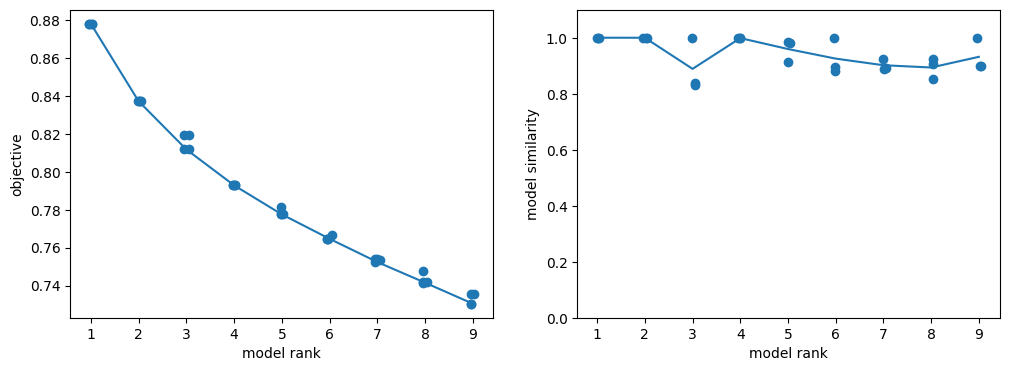

In [ ]:
ranks = range(1, 10) # change to 4 replicas,

ensemble = tt.Ensemble(fit_method="ncp_hals")

ensemble.fit(trial_start_matrix, ranks=ranks, replicates=4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tt.plot_objective(ensemble, ax=axes[0])
tt.plot_similarity(ensemble, ax=axes[1])
plt.show()

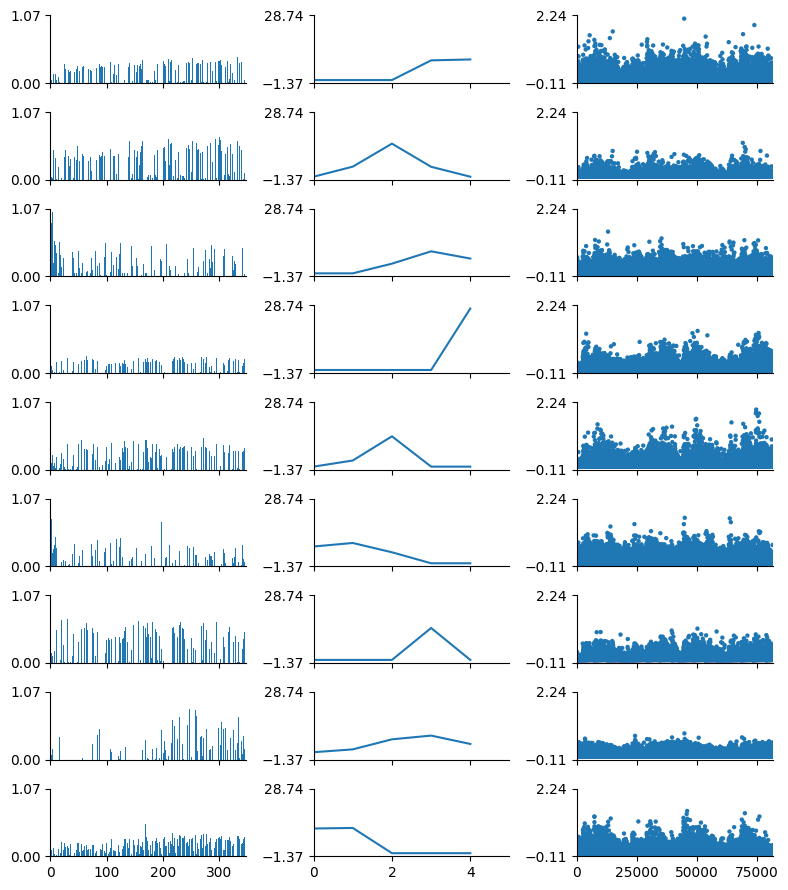

In [ ]:
optimal_rank = 9
replicate = 0
factors = ensemble.factors(optimal_rank)[replicate]
tt.plot_factors(factors, plots=['bar', 'line', 'scatter']
               )
plt.show()

In [ ]:
with open(f'{target_file}.pkl', 'wb') as f:
    pickle.dump(ensemble, f)

## Auto runnnig TCA as batch jobs

In [ ]:
def TCA_auto(target_file, target_path, ranks, replicates, beh_field, buffer):
  '''
  This function automates all of the previous cells, it runs TCA on the target mouse and then saves the TCA ensemble in a pickle file.
  The arguments are:
  target_file: The name of the file that should be used as input
  target_path: The path of the behavioural data
  ranks: The number of ranks for which TCA will be run
  replicates: The number of replicates that will be created during TCA for each rank
  beh_field: The field from beh that will be used as the center for creating the matrix
  buffer: The buffers that will be used around the centre, needs both left nd right buffer
  '''

  # Loading spiking data
  spiking_raw_data = np.load(os.path.join(root, target_file + '_SVD_dec.npy'), allow_pickle=True)

  # Loading behavioural data
  beh = np.load(os.path.join(root, target_path), allow_pickle=1).item()[target_file]

  # Reconstructing spiking data
  spiking_data = spiking_raw_data.item()['U'].T @ spiking_raw_data.item()['V']
  spiking_data = spiking_data.T

  # Z scoring the spiking data
  spiking_data = (spiking_data - np.mean(spiking_data)) / np.std(spiking_data)

  # Correcting for size
  size = min(len(beh['ft']), spiking_data.shape[0])

  # Creating the matrix
  trial_matrix = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])

  # Deleting unnecessary objects
  del(spiking_raw_data)
  del(beh)
  del(spiking_data)
  del(size)
  gc.collect()

  # Running TCA
  ranks = range(1, ranks)
  ensemble = tt.Ensemble(fit_method="cp_als")
  ensemble.fit(trial_matrix, ranks=ranks, replicates=replicates)

  # Deleting unnecessary objects
  del(trial_matrix)
  gc.collect()

  return ensemble

In [ ]:
TCA_auto(target_file, target_path, 10, 4, "Trial_start_time", (2, 2))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 6.5s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 27.7s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 53.3s


Rank-4 models:  min obj, 0.79;  max obj, 0.79;  time to fit, 110.6s


Rank-5 models:  min obj, 0.78;  max obj, 0.78;  time to fit, 89.3s


Rank-6 models:  min obj, 0.76;  max obj, 0.77;  time to fit, 127.7s


Rank-7 models:  min obj, 0.75;  max obj, 0.75;  time to fit, 167.9s


Rank-8 models:  min obj, 0.74;  max obj, 0.74;  time to fit, 166.2s


Rank-9 models:  min obj, 0.73;  max obj, 0.74;  time to fit, 158.3s


In [ ]:
# @title Running TCA for all the conditions for both sound cue and trial start time

target_file_list = [sup_bef, sup_aft, unsup_bef, unsup_aft]

for target_file in target_file_list:

  # Select appropriate target file
  if target_file == sup_bef:
    target_path = "Beh_sup_train1_before_learning.npy"
    save_path = "Beh_sup_train1_before_learning_ensemble"
  elif target_file == sup_aft:
    target_path = "Beh_sup_train1_after_learning.npy"
    save_path = "Beh_sup_train1_after_learning_ensemble"
  elif target_file == unsup_bef:
    target_path = "Beh_unsup_train1_before_learning.npy"
    save_path = "Beh_unsup_train1_before_learning_ensemble"
  elif target_file == unsup_aft:
    target_path = "Beh_unsup_train1_after_learning.npy"
    save_path = "Beh_unsup_train1_after_learning_ensemble"

  # Perform TCA and store the file for start time
  start_ensemble = TCA_auto(target_file, target_path, 10, 4, "Trial_start_time", (2, 8))
  joblib.dump(start_ensemble, os.path.join(drive_root, save_path + "_start.joblib"), compress=3)
  del(start_ensemble)
  gc.collect()

  # Perform TCA and store the file for sound time
  sound_ensemble = TCA_auto(target_file, target_path, 10, 4, "SoundTime", (5, 5))
  joblib.dump(sound_ensemble, os.path.join(drive_root, save_path + "_sound.joblib"), compress=3)
  del(sound_ensemble)
  gc.collect()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
                                                                    

Rank-1 models:  min obj, 0.96;  max obj, 0.96;  time to fit, 45.3s


Rank-2 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 157.6s


Rank-3 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 123.1s


Rank-4 models:  min obj, 0.87;  max obj, 0.87;  time to fit, 242.1s


...

Rank-3 models:  min obj, 0.91;  max obj, 0.91;  time to fit, 133.3s


Rank-4 models:  min obj, 0.90;  max obj, 0.90;  time to fit, 182.4s


Rank-5 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 281.2s


Rank-6 models:  min obj, 0.87;  max obj, 0.88;  time to fit, 331.0s


Fitting rank-7 models:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
def TCA_segmented_auto(target_file, target_path, ranks, replicates, beh_field, buffer):
  '''
  This function automates all of the previous cells, it runs TCA on the target mouse brain region and then saves the TCA ensemble in a pickle file.
  The arguments are:
  target_file: The name of the file that should be used as input
  target_path: The path of the behavioural data
  ranks: The number of ranks for which TCA will be run
  replicates: The number of replicates that will be created during TCA for each rank
  beh_field: The field from beh that will be used as the center for creating the matrix
  buffer: The buffers that will be used around the centre, needs both left nd right buffer
  '''

  # Loading spiking data
  spiking_raw_data = np.load(os.path.join(root, target_file + '_SVD_dec.npy'), allow_pickle=True)

  # Loading location data
  spiking_loc_data = np.load(os.path.join(root, target_file[:-2] + '_trans.npz'), allow_pickle=True)

  # Loading behavioural data
  beh = np.load(os.path.join(root, target_path), allow_pickle=1).item()[target_file]

  # Reconstructing spiking data
  spiking_data = spiking_raw_data.item()['U'].T @ spiking_raw_data.item()['V']
  spiking_data = spiking_data.T

  # Correcting for size
  size = min(len(beh['ft']), spiking_data.shape[0])

  # Creating trial matrices for each area
  area_name = ['V1', 'mHV', 'lHV', 'aHV']
  for ar in area_name:
      if ar=='V1':
        idx = np.where(np.isin(spiking_loc_data["iarea"], [8]))[0]
        trial_matrix_V1 = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])
      elif ar=='mHV':
        idx = np.where(np.isin(spiking_loc_data["iarea"], [0, 1, 2, 9]))[0]
        trial_matrix_mHV = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])
      elif ar=='lHV':
        idx = np.where(np.isin(spiking_loc_data["iarea"], [5, 6]))[0]
        trial_matrix_lHV = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])
      elif ar=='aHV':
        idx = np.where(np.isin(spiking_loc_data["iarea"], [3, 4]))[0]
        trial_matrix_aHV = create_3d_matrix(beh[beh_field], buffer, spiking_data, beh['ft'][:size + 1])

  # Deleting unnecessary objects
  del(spiking_raw_data)
  del(spiking_loc_data)
  del(beh)
  del(spiking_data)
  del(size)
  gc.collect()

  # Running TCA
  ranks = range(1, ranks)
  for ar in area_name:
      if ar=='V1':
        ensemble_V1 = tt.Ensemble(fit_method="ncp_hals")
        ensemble_V1.fit(trial_matrix_V1, ranks=ranks, replicates=replicates)
      elif ar=='mHV':
        ensemble_mHV = tt.Ensemble(fit_method="ncp_hals")
        ensemble_mHV.fit(trial_matrix_mHV, ranks=ranks, replicates=replicates)
      elif ar=='lHV':
        ensemble_lHV = tt.Ensemble(fit_method="ncp_hals")
        ensemble_lHV.fit(trial_matrix_lHV, ranks=ranks, replicates=replicates)
      elif ar=='aHV':
        ensemble_aHV = tt.Ensemble(fit_method="ncp_hals")
        ensemble_aHV.fit(trial_matrix_aHV, ranks=ranks, replicates=replicates)

  # Deleting unnecessary objects
  del(trial_matrix_V1)
  del(trial_matrix_mHV)
  del(trial_matrix_lHV)
  del(trial_matrix_aHV)
  gc.collect()

  return ensemble_V1, ensemble_mHV, ensemble_lHV, ensemble_aHV

In [ ]:
ensemble_V1, ensemble_mHV, ensemble_lHV, ensemble_aHV = TCA_segmented_auto(target_file, target_path, 5, 4, "Trial_start_time", (2, 2))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
                                                                    

Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 11.4s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 42.0s


Rank-3 models:  min obj, 0.81;  max obj, 0.82;  time to fit, 67.2s


Rank-4 models:  min obj, 0.79;  max obj, 0.80;  time to fit, 151.1s


...

Rank-4 models:  min obj, 0.79;  max obj, 0.80;  time to fit, 107.2s


Rank-1 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 11.5s


Rank-2 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 43.3s


Rank-3 models:  min obj, 0.82;  max obj, 0.82;  time to fit, 79.1s


Rank-4 models:  min obj, 0.79;  max obj, 0.80;  time to fit, 148.6s


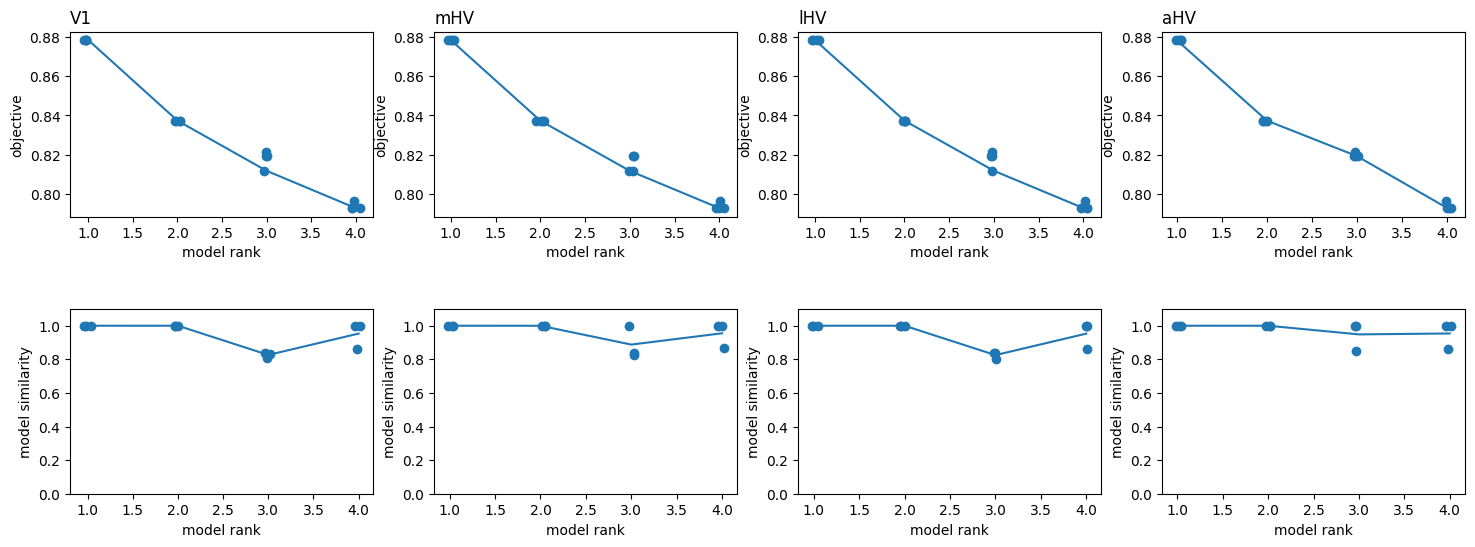

In [ ]:
regional_ensembles = [ensemble_V1, ensemble_mHV, ensemble_lHV, ensemble_aHV]
regional_ensemble_names = ["V1", "mHV", "lHV", "aHV"]

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
plt.subplots_adjust(hspace=0.5)
for idx, ensemble in enumerate(regional_ensembles):
  axes[0][idx].set_title(regional_ensemble_names[idx], loc='left')
  tt.plot_objective(ensemble, ax=axes[0][idx])
  tt.plot_similarity(ensemble, ax=axes[1][idx])
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_cp_ensemble(ensemble, rank, trial_stim_ids, save_path=None):

    # -----------------------------
    # Extract fits at selected rank
    # -----------------------------
    if isinstance(ensemble.results, dict):
        fits = ensemble.results[rank]
    else:
        fits = ensemble.results

    # If multiple replicates, select best by objective
    if isinstance(fits, (list, tuple)):

        def get_obj(fit):
            if hasattr(fit, "obj"):
                return fit.obj
            if hasattr(fit, "loss"):
                return fit.loss
            if hasattr(fit, "objective"):
                return fit.objective
            raise AttributeError("No objective attribute found.")

        objectives = np.array([get_obj(fit) for fit in fits])
        best_fit = fits[np.argmin(objectives)]

    else:
        best_fit = fits

    # -----------------------------
    # Extract factors
    # -----------------------------
    factors = best_fit.factors
    if hasattr(factors, "factors"):
        factors = factors.factors

    trial_stim_ids = np.asarray(trial_stim_ids).squeeze()
    n_behavior_trials = len(trial_stim_ids)

    # -----------------------------
    # Identify trial mode
    # -----------------------------
    trial_mode = None
    for i, F in enumerate(factors):
        if F.shape[0] == n_behavior_trials:
            trial_mode = i
            break

    if trial_mode is None:
        raise ValueError(
            f"No tensor mode matches trial count {n_behavior_trials}. "
            f"Factor shapes: {[F.shape for F in factors]}"
        )

    W = factors[trial_mode]

    other_modes = [i for i in range(len(factors)) if i != trial_mode]
    U = factors[other_modes[0]]
    V = factors[other_modes[1]]

    # Rank
    R = W.shape[1]

    # -----------------------------
    # Plot setup
    # -----------------------------
    fig_height = max(2.5, min(2.2 * R, 18))
    fig, axes = plt.subplots(R, 3, figsize=(12, fig_height))

    if R == 1:
        axes = np.array([axes])

    u_min, u_max = np.nanmin(U), np.nanmax(U)
    v_min, v_max = np.nanmin(V), np.nanmax(V)
    w_min, w_max = np.nanmin(W), np.nanmax(W)

    unique_stims = np.unique(trial_stim_ids)
    cmap = plt.get_cmap("tab10")
    stim_colors = {stim: cmap(i % 10) for i, stim in enumerate(unique_stims)}

    # -----------------------------
    # Plot components
    # -----------------------------
    for k in range(R):

        # Mode 1
        axes[k, 1].plot(np.arange(U.shape[0]), U[:, k])
        axes[k, 1].set_ylim(u_min, u_max)
        axes[k, 1].set_title(f"Mode {other_modes[0]} comp {k+1}")

        # Mode 2
        axes[k, 0].plot(np.arange(V.shape[0]), V[:, k])
        axes[k, 0].set_ylim(v_min, v_max)
        axes[k, 0].set_title(f"Mode {other_modes[1]} comp {k+1}")

        # Trial mode
        for stim in unique_stims:
            mask = trial_stim_ids == stim
            axes[k, 2].scatter(
                np.where(mask)[0],
                W[mask, k],
                s=10,
                color=stim_colors[stim],
                label=str(stim) if k == 0 else None
            )

        axes[k, 2].set_ylim(w_min, w_max)
        axes[k, 2].set_title(f"Trial mode comp {k+1}")

    axes[0, 2].legend(title="Stimulus", fontsize=8)

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150)
        print(f"Saved to {save_path}")

    plt.show()


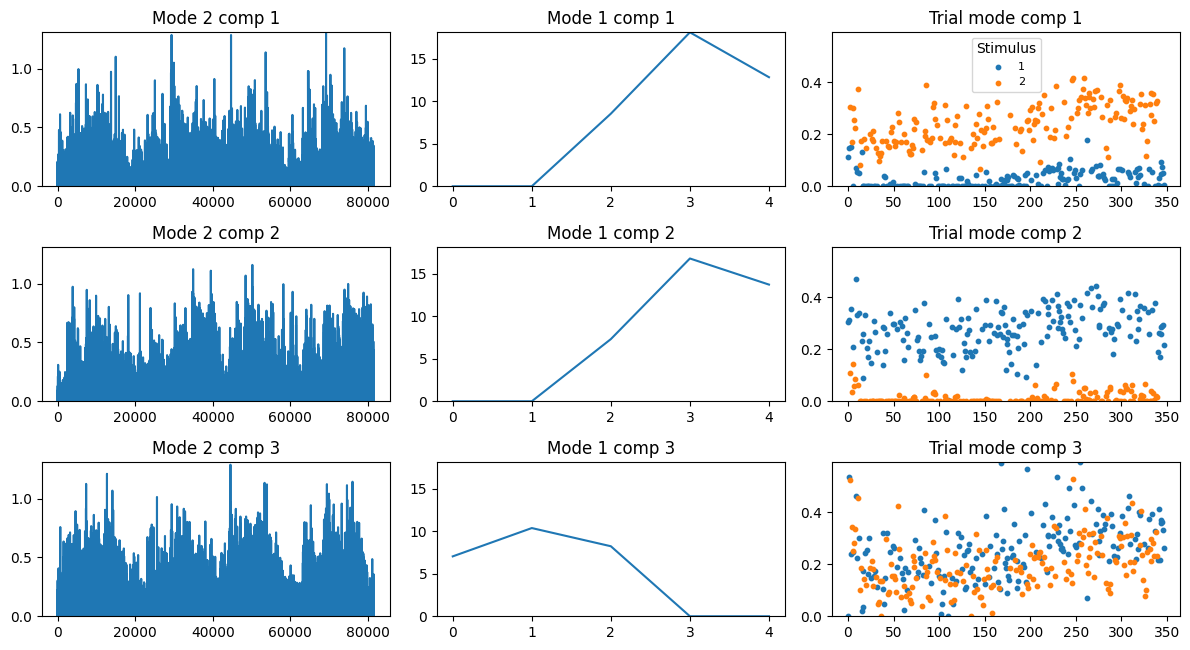

In [ ]:
plot_cp_ensemble(ensemble_V1, 3, beh["WallType"])

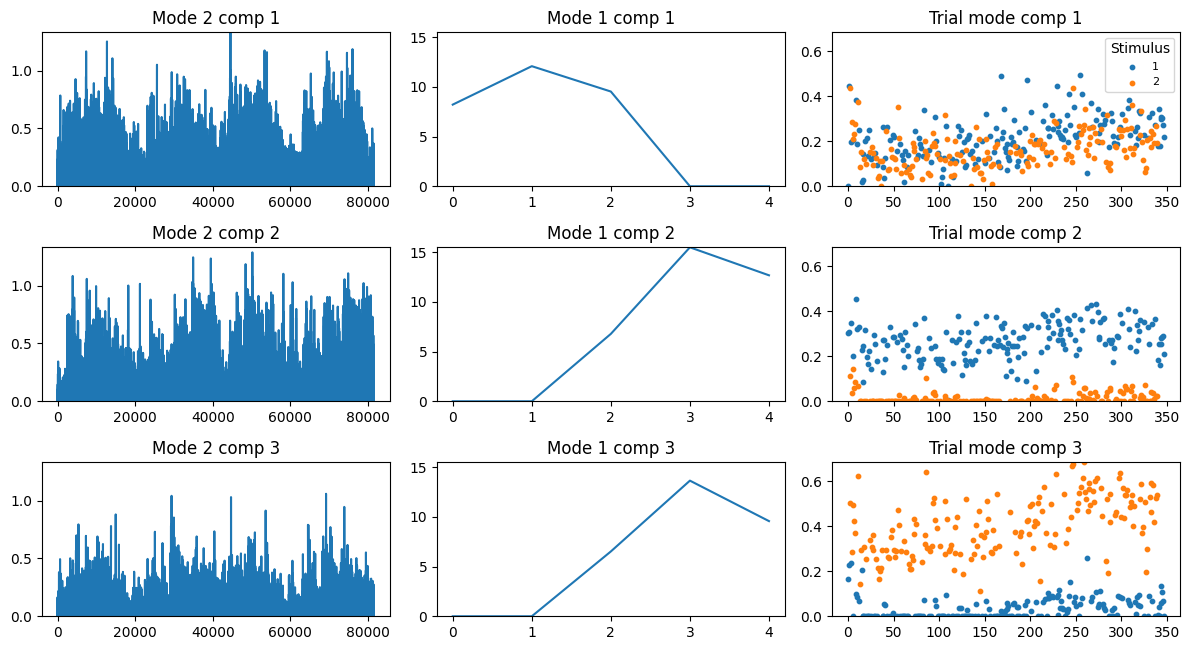

In [ ]:
plot_cp_ensemble(ensemble_mHV, 3, beh["WallType"])

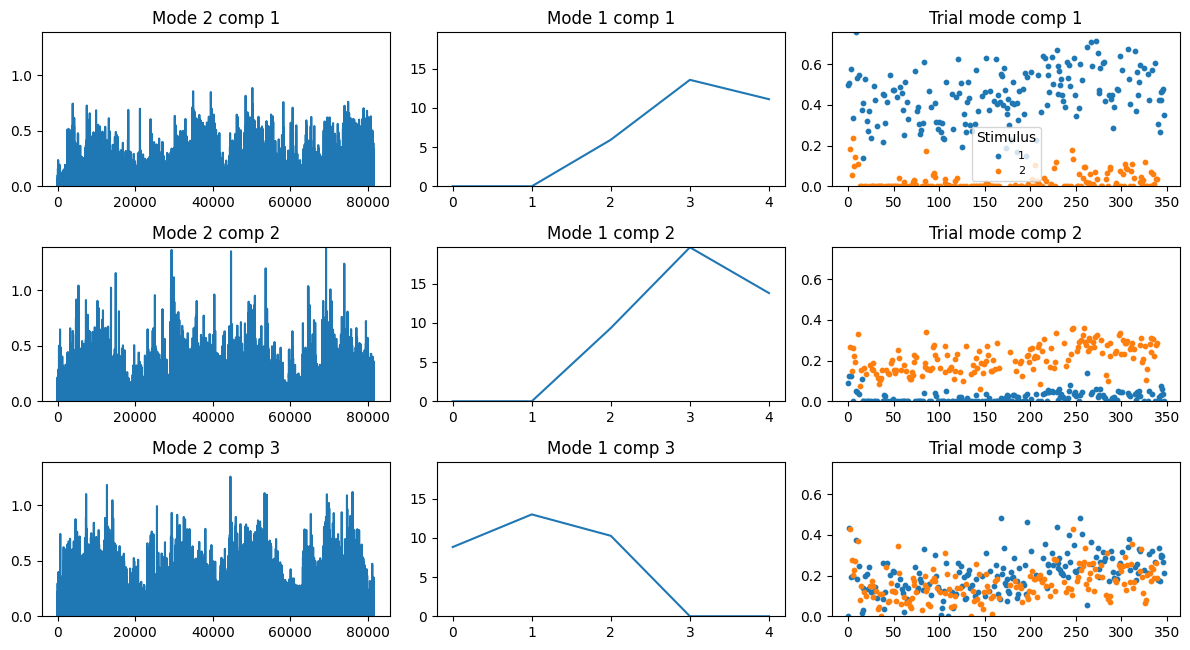

In [ ]:
plot_cp_ensemble(ensemble_lHV, 3, beh["WallType"])

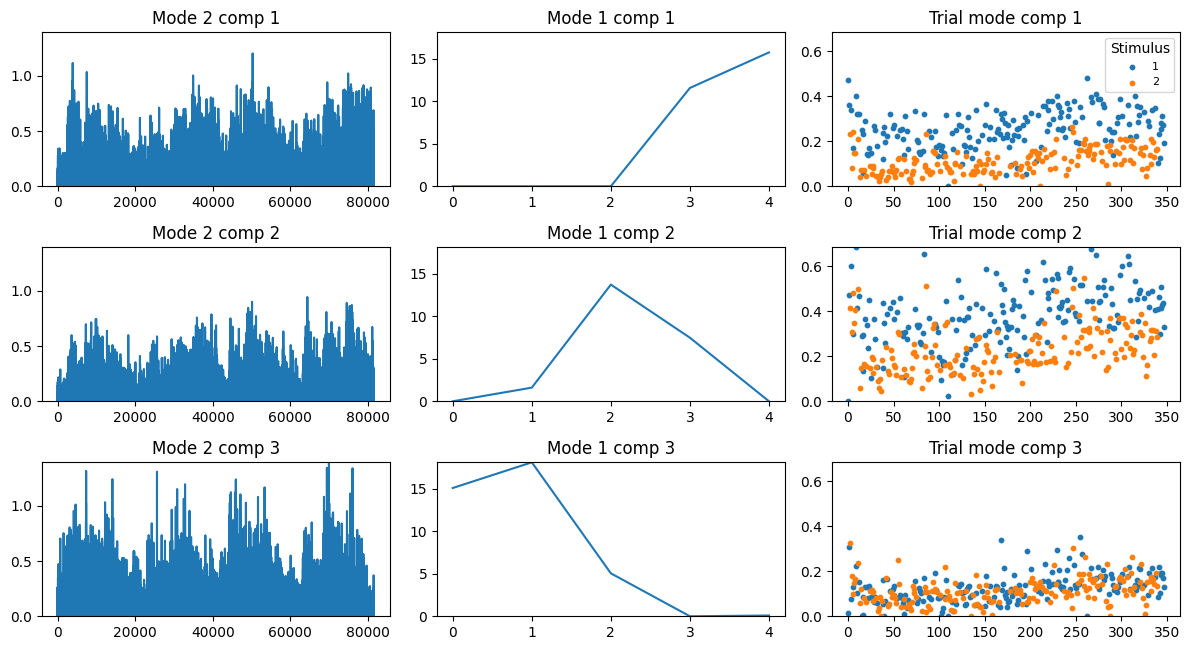

In [ ]:
plot_cp_ensemble(ensemble_aHV, 3, beh["WallType"])